In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif

In [6]:
data = {
    "Gender": ["Male","Female","Female","Male","Male","Female","Male","Female"],
    "Department": ["IT","HR","Finance","IT","Finance","HR","IT","Finance"],
    "Education": ["High","Medium","Low","High","Medium","Low","High","Medium"],
    "Age": [22,25,28,30,35,40,26,31],
    "Salary": [30000,35000,40000,50000,65000,70000,45000,60000],
    "Selected": [1,0,1,1,0,0,1,1]
}

df = pd.DataFrame(data)

print("Sample Dataset")
display(df)

Sample Dataset


,Gender,Department,Education,Age,Salary,Selected
0,Male,IT,High,22,30000,1
1,Female,HR,Medium,25,35000,0
2,Female,Finance,Low,28,40000,1
3,Male,IT,High,30,50000,1
4,Male,Finance,Medium,35,65000,0
5,Female,HR,Low,40,70000,0
6,Male,IT,High,26,45000,1
7,Female,Finance,Medium,31,60000,1


In [7]:
# Label Encoder
label_encoder = LabelEncoder()
df["Gender_Label"] = label_encoder.fit_transform(df["Gender"])

# Ordinal Encoder
ordinal_encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
df["Education_Ordinal"] = ordinal_encoder.fit_transform(df[["Education"]])

# One Hot Encoder
one_hot = pd.get_dummies(df, columns=["Department"])

print("Encoded Dataset")
display(one_hot)

Encoded Dataset


,Gender,Education,Age,Salary,Selected,Gender_Label,Education_Ordinal,Department_Finance,Department_HR,Department_IT
0,Male,High,22,30000,1,1,2.0,False,False,True
1,Female,Medium,25,35000,0,0,1.0,False,True,False
2,Female,Low,28,40000,1,0,0.0,True,False,False
3,Male,High,30,50000,1,1,2.0,False,False,True
4,Male,Medium,35,65000,0,1,1.0,True,False,False
5,Female,Low,40,70000,0,0,0.0,False,True,False
6,Male,High,26,45000,1,1,2.0,False,False,True
7,Female,Medium,31,60000,1,0,1.0,True,False,False


In [8]:
features = df[["Age", "Salary"]]

standard = StandardScaler()
minmax = MinMaxScaler()
robust = RobustScaler()

standard_data = standard.fit_transform(features)
minmax_data = minmax.fit_transform(features)
robust_data = robust.fit_transform(features)

print("StandardScaler")
print(standard_data)

print("\nMinMaxScaler")
print(minmax_data)

print("\nRobustScaler")
print(robust_data)

StandardScaler
[[-1.41023972 -1.4284046 ]
 [-0.8553913  -1.05978406]
 [-0.30054289 -0.69116352]
 [ 0.06935605  0.04607757]
 [ 0.99410341  1.15193919]
 [ 1.91885076  1.52055974]
 [-0.67044183 -0.32254297]
 [ 0.25430552  0.78331865]]

MinMaxScaler
[[0.         0.        ]
 [0.16666667 0.125     ]
 [0.33333333 0.25      ]
 [0.44444444 0.5       ]
 [0.72222222 0.875     ]
 [1.         1.        ]
 [0.22222222 0.375     ]
 [0.5        0.75      ]]

RobustScaler
[[-1.12       -0.77777778]
 [-0.64       -0.55555556]
 [-0.16       -0.33333333]
 [ 0.16        0.11111111]
 [ 0.96        0.77777778]
 [ 1.76        1.        ]
 [-0.48       -0.11111111]
 [ 0.32        0.55555556]]


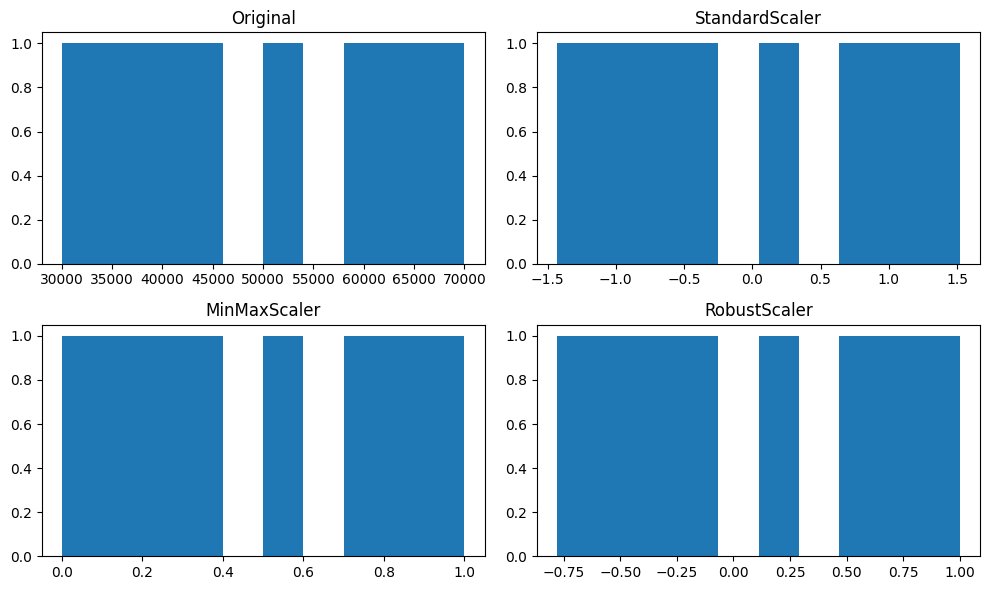

In [9]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.hist(features["Salary"])
plt.title("Original")

plt.subplot(2,2,2)
plt.hist(standard_data[:,1])
plt.title("StandardScaler")

plt.subplot(2,2,3)
plt.hist(minmax_data[:,1])
plt.title("MinMaxScaler")

plt.subplot(2,2,4)
plt.hist(robust_data[:,1])
plt.title("RobustScaler")

plt.tight_layout()
plt.show()

In [10]:
X = df[["Age","Salary","Gender_Label","Education_Ordinal"]]
y = df["Selected"]

selector = SelectKBest(score_func=f_classif, k=4)

selector.fit(X,y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

print(scores.sort_values(by="Score", ascending=False))

             Feature     Score
0                Age  2.359313
3  Education_Ordinal  1.564655
1             Salary  1.258562
2       Gender_Label  0.428571


In [ ]:
Observations:

1. LabelEncoder converted Gender into numeric values.
2. OneHotEncoder created separate columns for Department.
3. OrdinalEncoder preserved the order Low < Medium < High.
4. StandardScaler standardized the numerical features.
5. MinMaxScaler scaled values between 0 and 1.
6. RobustScaler handled scaling while reducing the influence of outliers.
7. SelectKBest ranked the features according to their importance.